# Chapter 118 — Geometry in Game Development

> **Prerequisites:** ch094 (Distance), ch109 (Rotation), ch114 (Affine), ch099 (Circles)
>
> **Outcomes:** Implement collision detection; Do vector-based movement; Detect and resolve collisions; Understand spatial partitioning


## Core Game Geometry

Games reduce to geometry:
- **Position:** point (x, y)
- **Velocity:** vector (vx, vy)
- **Update rule:** p_new = p_old + v·dt
- **Collision:** test whether two shapes overlap

The most common collision primitives:
- **Circle vs Circle:** d(c1, c2) < r1 + r2
- **AABB vs AABB** (axis-aligned bounding box): overlapping x and y ranges
- **Point in circle:** d(p, center) < r
- **Point in AABB:** xmin≤px≤xmax and ymin≤py≤ymax

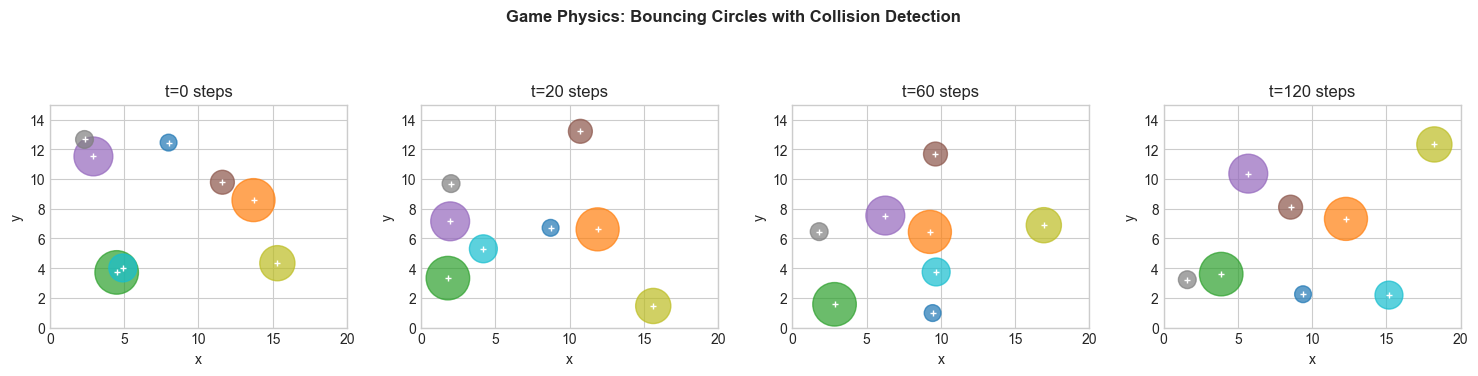

In [1]:
# --- Game physics demo: bouncing circles ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
N_BALLS = 8
BOX = (0, 20, 0, 15)  # xmin, xmax, ymin, ymax

positions = np.random.uniform([2,2],[18,13],(N_BALLS,2))
velocities = np.random.randn(N_BALLS, 2) * 3
radii = np.random.uniform(0.5, 1.5, N_BALLS)
colors = plt.cm.tab10(np.linspace(0,1,N_BALLS))

def bounce_step(pos, vel, radii, box, dt=0.05):
    """One physics step: move, bounce off walls, resolve ball collisions."""
    pos = pos + vel * dt
    xmin, xmax, ymin, ymax = box
    
    # Wall bouncing
    for i in range(len(pos)):
        r = radii[i]
        if pos[i,0] - r < xmin: pos[i,0] = xmin + r; vel[i,0] = abs(vel[i,0])
        if pos[i,0] + r > xmax: pos[i,0] = xmax - r; vel[i,0] = -abs(vel[i,0])
        if pos[i,1] - r < ymin: pos[i,1] = ymin + r; vel[i,1] = abs(vel[i,1])
        if pos[i,1] + r > ymax: pos[i,1] = ymax - r; vel[i,1] = -abs(vel[i,1])
    
    # Ball-ball collision (elastic)
    for i in range(len(pos)):
        for j in range(i+1, len(pos)):
            diff = pos[j] - pos[i]
            dist = np.linalg.norm(diff)
            min_dist = radii[i] + radii[j]
            if dist < min_dist and dist > 1e-10:
                normal = diff / dist
                # Separate overlapping balls
                overlap = min_dist - dist
                pos[i] -= 0.5 * overlap * normal
                pos[j] += 0.5 * overlap * normal
                # Exchange velocity components along normal
                vi_n = np.dot(vel[i], normal)
                vj_n = np.dot(vel[j], normal)
                vel[i] += (vj_n - vi_n) * normal
                vel[j] += (vi_n - vj_n) * normal
    return pos, vel

# Simulate and plot snapshots
fig, axes = plt.subplots(1,4,figsize=(15,4))
pos, vel = positions.copy(), velocities.copy()
for ax, step in zip(axes, [0, 20, 60, 120]):
    for _ in range(step if ax == axes[0] else 20):
        pos, vel = bounce_step(pos, vel, radii, BOX)
    ax.set_xlim(*BOX[:2]); ax.set_ylim(*BOX[2:]); ax.set_aspect('equal')
    for i in range(N_BALLS):
        circle = plt.Circle(pos[i], radii[i], color=colors[i], alpha=0.7)
        ax.add_patch(circle)
        ax.plot(*pos[i], '+', color='white', ms=5)
    ax.set_title(f't={step} steps')
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Game Physics: Bouncing Circles with Collision Detection', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Spatial Partitioning

For N objects, checking all pairs is O(N²). Spatial partitioning reduces this:

**Grid partitioning:** divide space into cells; only check objects in neighboring cells.
For uniform-radius objects: O(N) average-case collision detection.

**Quadtree:** recursively divide space into 4 quadrants; store objects at appropriate level.
Used in: game engines, GIS systems, particle simulations.

For N=1000 objects, O(N²) = 500,000 checks; grid with c cells ≈ N·(9 checks each) = 9000 checks.

## Summary

- Game geometry: position=point, velocity=vector, update=point+vector*dt
- Circle collision: d < r1+r2; AABB: check x and y ranges separately
- Elastic collision: exchange normal velocity components
- Spatial partitioning reduces O(N²) to O(N) with grids or quadtrees

**Forward:** ch120 (Physics Simulator) integrates all this into a full 2D physics engine.